# 02 · Physics-Informed Features — Telling the Model What to Listen For

**IUM teaching series, Notebook 2/4** · Wang & Zhao, *Additive Manufacturing*
(2026) 105300.

Raw waveforms have 62,509 points; we have only 50 printed samples. Learning
end-to-end from raw signals is hopeless at this scale (the paper proves it —
Case 1 fails). Instead, the paper *designs* features on a physical map:

![two-scale](https://raw.githubusercontent.com/wangyiquan1010-coder/IUM_teaching_colab/main/figs/two_scale_framework.png)

- **Across layers**: each layer lengthens the acoustic path *and* stiffens the
  material → ToF, amplitude ratio, spectral features encode geometry + material
  state, entangled.
- **Within a layer**: during one 15 s exposure the printhead does not move — the
  path is frozen. The six frames differ *only* through crosslinking → frame-to-
  frame change is a **geometry-immune** probe of curing (→ DoC).

This notebook rebuilds the key features from raw data and then asks, honestly,
how much process information they carry *before any learning* — which turns out
to be a great deal for some of them and very little for others.


### Before we run anything: the setup cell

**Input** — nothing from your side. On Google Colab this cell downloads the
course repository (`github.com/wangyiquan1010-coder/IUM_teaching_colab`), which
ships *all* the data used in this series; running locally, it just finds the
repository folder you already have.

**What this cell does** — clones the repo if needed, moves the working
directory to the repository root (so that every later path like
`data/feature11.csv` resolves), and imports the four things we use everywhere:
`numpy` (signal math), `pandas` (tables), `matplotlib` (plots) and
`ium_utils` — **our own teaching library**, a clean, read-only refactor of the
paper's code that lives in `src/ium_utils.py`. Feel free to open that file at
any point: every function used in the notebooks is defined there, with comments.

**Output** — the imported modules plus a confirmation line printing the
repository root. Nothing is computed yet.


In [1]:
# --- Setup (works both locally and on Google Colab) ---------------------------
# On Colab the notebook starts in an empty machine, so we first download
# ("clone") the whole course repository, which contains the data, the helper
# library and the figures. Locally the files are already next to the notebook,
# so the clone is skipped.
import os, sys

if "google.colab" in sys.modules and not os.path.exists("src"):
    !git clone -q https://github.com/wangyiquan1010-coder/IUM_teaching_colab.git
    %cd IUM_teaching_colab

# Walk up the folder tree until we find the repository root (the folder that
# contains src/). This makes every later path such as "data/feature11.csv"
# work no matter where the notebook was launched from.
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, "src")):
    _parent = os.path.dirname(_here)
    if _parent == _here:
        raise FileNotFoundError("repo root with src/ not found")
    _here = _parent
os.chdir(_here)
sys.path.insert(0, "src")            # so that "import ium_utils" works

import numpy as np                   # arrays / signal math
import pandas as pd                  # tables (features, labels, results)
import matplotlib.pyplot as plt      # static plots
from matplotlib import rc
rc("animation", html="jshtml")       # render animations as interactive players
import ium_utils as iu               # OUR course library (see src/ium_utils.py)
print("setup ok — repo root:", _here)


setup ok — repo root: C:\Users\wangy\Desktop\IUM_teaching_colab


### Loading the controlled pair again

**Input** — the same two `.npz` archives as in Notebook 1: `15L @ I1` (weak
cure) and `15L @ I7` (strong cure). Same geometry, same resin, only the light
intensity differs, so every difference we measure below is a **material**
difference.

**What this cell does** — reloads the waveforms, rebuilds the time axis, and
re-runs the B1/B2 tracker. Each notebook stands on its own, so nothing carries
over from Notebook 1's kernel.

**Output** — `wf_i1`, `wf_i7` (arrays of shape 15 × 6 × 62509), `t_us`, and the
tracking tables `track_i1`, `track_i7` (`b1_idx`, `b2_idx`, `tof_us` per layer)
that every feature below is computed *relative to*.


In [2]:
# Same controlled pair as Notebook 1: identical geometry, different light dose.
wf_i1, _ = iu.load_sample("data/waveforms_15L_I1.npz")   # weak cure
wf_i7, _ = iu.load_sample("data/waveforms_15L_I7.npz")   # strong cure
t_us = iu.time_axis_us()

# Echo positions are the anchor for every feature: all windows below are placed
# relative to the tracked B2 index, never at a fixed absolute time.
track_i1 = iu.track_sample(wf_i1)
track_i7 = iu.track_sample(wf_i7)


## 1. The within-layer scale, animated

Fix one layer. Play its six frames (reference + five during exposure), zoomed
to the B2 echo. The path cannot change — everything you see moving is
**chemistry**.

---

Both panels are **normalised to their own first frame**, so they share one
vertical scale and can be compared directly: every trace starts at ±1, and what
you watch is the *fraction* of the echo that survives as curing proceeds.

> The strongly cured echo is about five times weaker in raw counts, so fewer
> digitizer steps describe it and its trace looks coarser. Nothing is smoothed —
> that is quantization, not filtering.

---

**Input** — one single layer (layer 8) of each print, i.e. `wf_i1[7]` and
`wf_i7[7]`: **6 frames × 62,509 points** each. This time the animation's frames
are the *within-layer* snapshots, not layers.

**What this cell does** — cuts a ±500-sample window (±0.2 µs) centred on that
layer's tracked B2 position, normalises it by the reference frame, and animates
the six frames. Because the printhead does not move during an exposure, the
window content can only change through curing.

**Output** — a two-panel animation plus the per-frame amplitude. Both bursts
weaken during the 15 s exposure, the strongly cured one more steeply (about
−19% against −8%). That is one layer of one print, not a rule — section 4 puts
the question to all 50.


In [3]:
from matplotlib.animation import FuncAnimation

LAYER = 8                                    # any mid-print layer works
r1, r7 = track_i1.iloc[LAYER-1], track_i7.iloc[LAYER-1]
w1 = 500                                     # half-window: 500 samples = 0.2 µs

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
arts = []
for ax, (wfS, r, name) in zip(axes, [(wf_i1, r1, "I1 (weak cure)"),
                                     (wf_i7, r7, "I7 (strong cure)")]):
    b2 = int(r.b2_idx)                       # window follows the echo, not the clock
    seg_t = t_us[b2-w1:b2+w1]
    block = wfS[LAYER-1, :, b2-w1:b2+w1].astype(float)   # (6 frames, 2*w1)
    # Remove ONE common baseline (the digitizer's DC offset) from all six frames
    # so the burst is centred on zero. A single offset for the whole layer keeps
    # the frame-to-frame differences - the thing we came to see - intact.
    block = block - np.median(block)
    # Normalise by the REFERENCE frame, again one number for the whole layer.
    # Both panels then start at +-1 and share the axis below, so the amount of
    # motion you see is directly comparable between weak and strong cure.
    block = block / np.abs(block[0]).max()
    ln, = ax.plot([], [], lw=1.2)
    tx = ax.text(0.03, 0.9, "", transform=ax.transAxes)
    ax.set(xlim=(seg_t[0], seg_t[-1]), ylim=(-1.25, 1.25), xlabel="time (µs)",
           title=f"{name} — layer {LAYER}")
    arts.append((ln, tx, seg_t, block))
axes[0].set_ylabel("amplitude / reference frame")

def upd(f):
    """Show frame f of the same layer in both panels (f=0 is the reference)."""
    out = []
    for ln, tx, seg_t, block in arts:
        ln.set_data(seg_t, block[f])
        tx.set_text(f"frame {f+1}/6  (t = {max(0,(f-1))*3} s)" if f else "reference")
        out += [ln, tx]
    return out

# Amplitude per frame, as a fraction of the reference frame — the same numbers
# the animation shows, now directly comparable between the two panels.
for name, (_, _, _, block) in zip(["I1 weak  ", "I7 strong"], arts):
    p2p = block.max(axis=1) - block.min(axis=1)
    print(f"{name} amplitude per frame: {np.round(p2p / p2p[0], 3)}   "
          f"({(p2p[-1] / p2p[0] - 1) * 100:+.0f}% over the exposure)")

ani = FuncAnimation(fig, upd, frames=6, interval=600, blit=False)
plt.close(fig)
ani


I1 weak   amplitude per frame: [1.    0.987 0.974 0.942 0.936 0.917]   (-8% over the exposure)
I7 strong amplitude per frame: [1.    0.906 0.937 0.906 0.875 0.812]   (-19% over the exposure)


The change is subtle by eye — which is precisely why we quantify it with
**within-layer RMS/STD** (frame-to-frame differences in the fixed window).

## 2. Rebuilding the layer-wise features

The paper describes **11 descriptors per layer**, and the dataset shipped with
this repository stores exactly that: 11 features × 30 layer slots = 330 numbers
per printed sample. Here is what each one measures and which scale it belongs
to.

**Across-layer features** — computed from the **final frame** of the layer (the
end of its exposure), all inside a ±800-sample window placed around the tracked
B2 echo:

<table style="border-collapse:collapse">
<thead><tr>
<th style="border:1px solid #999;padding:5px 9px;text-align:left">feature</th>
<th style="border:1px solid #999;padding:5px 9px;text-align:left">unit</th>
<th style="border:1px solid #999;padding:5px 9px;text-align:left">what it measures</th>
</tr></thead>
<tbody>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>ToF</code></td>
<td style="border:1px solid #999;padding:5px 9px">µs</td>
<td style="border:1px solid #999;padding:5px 9px">arrival-time difference B1 → B2. The acoustic path length divided by the wave speed, so it responds both to the part growing and to the material getting faster as it cures.</td></tr>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>amplitude</code></td>
<td style="border:1px solid #999;padding:5px 9px">–</td>
<td style="border:1px solid #999;padding:5px 9px">the B2/B1 envelope ratio, i.e. how much of the echo survives the trip through the part. Dividing by B1 is deliberate: B1 never leaves the printhead, so the ratio cancels drifts in transducer coupling or pulse energy and leaves attenuation.</td></tr>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>RMS_Energy</code></td>
<td style="border:1px solid #999;padding:5px 9px">a.u.</td>
<td style="border:1px solid #999;padding:5px 9px">root-mean-square amplitude of the B2 window — the total energy coming back, without normalising by B1.</td></tr>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>Center_Freq</code></td>
<td style="border:1px solid #999;padding:5px 9px">Hz</td>
<td style="border:1px solid #999;padding:5px 9px">the spectral centroid of the echo (2–30 MHz band). Cured polymer absorbs high frequencies more strongly than low ones, so the centroid moves as the material changes.</td></tr>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>Bandwidth</code></td>
<td style="border:1px solid #999;padding:5px 9px">Hz</td>
<td style="border:1px solid #999;padding:5px 9px">the spectral spread about that centroid — how much the pulse has been broadened and reshaped on its way through the part.</td></tr>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>Wavelet_Energy_L0</code> … <code>L3</code></td>
<td style="border:1px solid #999;padding:5px 9px">a.u.</td>
<td style="border:1px solid #999;padding:5px 9px">energy in four wavelet decomposition bands. Unlike the FFT-based pair above, a wavelet split keeps <em>where in the burst</em> the energy sits, so these four capture changes in the echo's shape that a single centroid would average away.</td></tr>
</tbody>
</table>

**Within-layer features** — computed from **all six frames** of the same, frozen
window, and therefore immune to geometry:

<table style="border-collapse:collapse">
<thead><tr>
<th style="border:1px solid #999;padding:5px 9px;text-align:left">feature</th>
<th style="border:1px solid #999;padding:5px 9px;text-align:left">unit</th>
<th style="border:1px solid #999;padding:5px 9px;text-align:left">what it measures</th>
</tr></thead>
<tbody>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>frame_diff_rms</code></td>
<td style="border:1px solid #999;padding:5px 9px">a.u.</td>
<td style="border:1px solid #999;padding:5px 9px">root-mean-square of the frame-to-frame differences: how much the echo moves from one 3 s snapshot to the next while the light is on.</td></tr>
<tr><td style="border:1px solid #999;padding:5px 9px"><code>within_layer_std</code></td>
<td style="border:1px solid #999;padding:5px 9px">a.u.</td>
<td style="border:1px solid #999;padding:5px 9px">the per-sample standard deviation across the six frames, averaged over the window: the same idea, measured as spread instead of as step-to-step change.</td></tr>
</tbody>
</table>

---

**Input** — the raw frames of one layer (`wf[li]`, shape 6 × 62509) plus that
layer's tracked `b1_idx` and `b2_idx`. Nothing else: every window below is
positioned relative to the echoes, never at a fixed absolute time.

**What this cell does** — computes all eleven descriptors from the raw samples,
written out step by step with the formula for each one, so you can see exactly
what every number in the dataset means. Nothing is read from a precomputed
file here.

**Output** — `F1` and `F7`: one row per layer, eleven columns, indexed by layer
number. The `.head()` call prints the first five rows so you can see the actual
values and units.


In [4]:
import pywt          # PyWavelets — preinstalled on Colab

WIN = 800            # half-width of the analysis window around B2 [samples]
                     # 800 samples = 0.32 µs, wide enough to hold the whole burst


def layer_features_explicit(frames, b1_idx, b2_idx):
    """The 11 layer-wise descriptors for ONE layer, computed from scratch.

    frames         : (6, 62509) all frames of this layer, raw amplitudes
    b1_idx, b2_idx : tracked echo positions for this layer [sample index]
    """
    f = {}
    x = frames[-1].astype(float)          # final frame = end of the exposure

    # --- envelope ----------------------------------------------------------
    # An echo is an oscillating burst whose individual peaks all look alike, so
    # we work with its envelope: the rectified signal, smoothed with a boxcar.
    #     env[n] = (1/K) * SUM_k |x[n-k] - median(x)| ,  K = 101 (= 40 ns)
    rect = np.abs(x - np.median(x))       # median removes the digitizer's DC offset
    env = np.convolve(rect, np.ones(101) / 101, mode="same")

    # --- 1. ToF ------------------------------------------------------------
    #     ToF = (b2 - b1) * dt ,   dt = 1 / 2.5 GHz = 0.4 ns
    f["ToF"] = (b2_idx - b1_idx) * iu.DT_NS / 1000.0                   # µs

    # --- 2. amplitude ratio -------------------------------------------------
    #     amplitude = env[b2] / env[b1]
    # Dividing by B1 is what makes this a *material* measurement: B1 never
    # leaves the printhead, so any drift in coupling or pulse energy scales
    # both echoes and cancels in the ratio.
    f["amplitude"] = float(env[b2_idx] / (env[b1_idx] + 1e-9))         # -

    # Every remaining across-layer feature reads the same window around B2.
    seg = x[b2_idx - WIN : b2_idx + WIN]               # 1600 samples = 0.64 µs

    # --- 3. RMS energy ------------------------------------------------------
    #     RMS = sqrt( mean( seg^2 ) )   — how much energy came back in total
    f["RMS_Energy"] = float(np.sqrt(np.mean(seg ** 2)))                # a.u.

    # --- 4 & 5. spectral centroid and bandwidth -----------------------------
    # Power spectrum of the echo (mean removed so the DC bin carries no weight):
    #     P(f) = |FFT(seg - mean(seg))|^2
    # Centroid  fc = SUM(f * P) / SUM(P)                   — "average" frequency
    # Bandwidth bw = sqrt( SUM((f - fc)^2 * P) / SUM(P) )  — its spread
    # Restricted to 2-30 MHz, the band where this 10 MHz transducer has gain.
    P = np.abs(np.fft.rfft(seg - seg.mean())) ** 2
    freqs = np.fft.rfftfreq(len(seg), d=1 / iu.FS)
    keep = (freqs >= 2e6) & (freqs <= 30e6)
    Pb, fb = P[keep], freqs[keep]
    fc = float((fb * Pb).sum() / Pb.sum())
    f["Center_Freq"] = fc                                              # Hz
    f["Bandwidth"] = float(np.sqrt(((fb - fc) ** 2 * Pb).sum() / Pb.sum()))

    # --- 6-9. wavelet-band energies -----------------------------------------
    # A Daubechies-4 transform with 3 levels splits the echo into four bands,
    # returned coarse-to-fine as [cA3, cD3, cD2, cD1]. The feature is each
    # band's energy:
    #     Wavelet_Energy_Lk = SUM( c_k^2 )
    # Why bother, when we already have a centroid? The FFT pair above averages
    # over the whole window and forgets WHEN each frequency arrived; wavelet
    # bands keep that, so they see changes in the burst's shape, not just its
    # average pitch.
    for k, c in enumerate(pywt.wavedec(seg, "db4", level=3)):
        f[f"Wavelet_Energy_L{k}"] = float(np.sum(c ** 2))              # a.u.

    # --- 10 & 11. within-layer features -------------------------------------
    # Same window, but now all six frames. The printhead does not move during
    # an exposure, so these two see chemistry and nothing else.
    block = frames[:, b2_idx - WIN : b2_idx + WIN].astype(float)
    diffs = np.diff(block, axis=0)              # 5 consecutive frame differences
    #     frame_diff_rms = mean_i( sqrt( mean( diff_i^2 ) ) )
    f["frame_diff_rms"] = float(np.mean([np.sqrt(np.mean(d ** 2)) for d in diffs]))
    #     within_layer_std = mean_n( std over the 6 frames at sample n )
    f["within_layer_std"] = float(np.std(block, axis=0).mean())
    return f


def features_for(wf, track):
    """Apply the above to every layer of one print -> one row per layer."""
    rows = []
    for li in range(wf.shape[0]):
        r = track.iloc[li]
        f = layer_features_explicit(wf[li], int(r.b1_idx), int(r.b2_idx))
        f["layer"] = li + 1
        rows.append(f)
    return pd.DataFrame(rows).set_index("layer")

F1 = features_for(wf_i1, track_i1)      # weak cure
F7 = features_for(wf_i7, track_i7)      # strong cure
print("features per layer:", F1.shape[1])
F1.head()


features per layer: 11


,ToF,amplitude,RMS_Energy,Center_Freq,Bandwidth,Wavelet_Energy_L0,Wavelet_Energy_L1,Wavelet_Energy_L2,Wavelet_Energy_L3,frame_diff_rms,within_layer_std
layer,,,,,,,,,,,
1,0.3900,3.054064,11495.298912,5.186293e+06,2.346960e+06,2.132961e+11,3.045389e+06,5.713420e+06,1.385172e+07,330.376043,291.991740
2,0.4516,2.928896,11046.787723,5.057970e+06,1.956700e+06,1.966672e+11,3.046960e+06,6.986681e+06,1.426006e+07,261.740257,187.094078
3,0.5192,2.951156,11052.838755,4.982653e+06,1.696513e+06,1.984698e+11,3.526261e+06,6.141830e+06,1.318010e+07,232.953408,161.703697
4,0.5876,2.922140,10932.661218,4.941027e+06,1.723480e+06,1.933101e+11,3.346526e+06,6.715088e+06,1.266723e+07,222.548706,144.425431
5,0.6508,2.813932,10628.819234,4.885328e+06,1.691499e+06,1.829691e+11,2.848513e+06,6.794934e+06,1.212554e+07,219.570395,140.570806


### Do the features separate the two intensities?

**Input** — the two freshly computed tables `F1` and `F7` (15 rows each).

**What this cell does** — plots four representative features against layer
index, one panel each, with both intensities overlaid. Each panel is titled with
the *physical* quantity the feature is meant to probe, so you can judge the
design rather than just the curve.

**Output** — a 2×2 figure. If the two colors separate here, the features already
carry process information **before any machine learning** — which is the whole
point of physics-informed design.


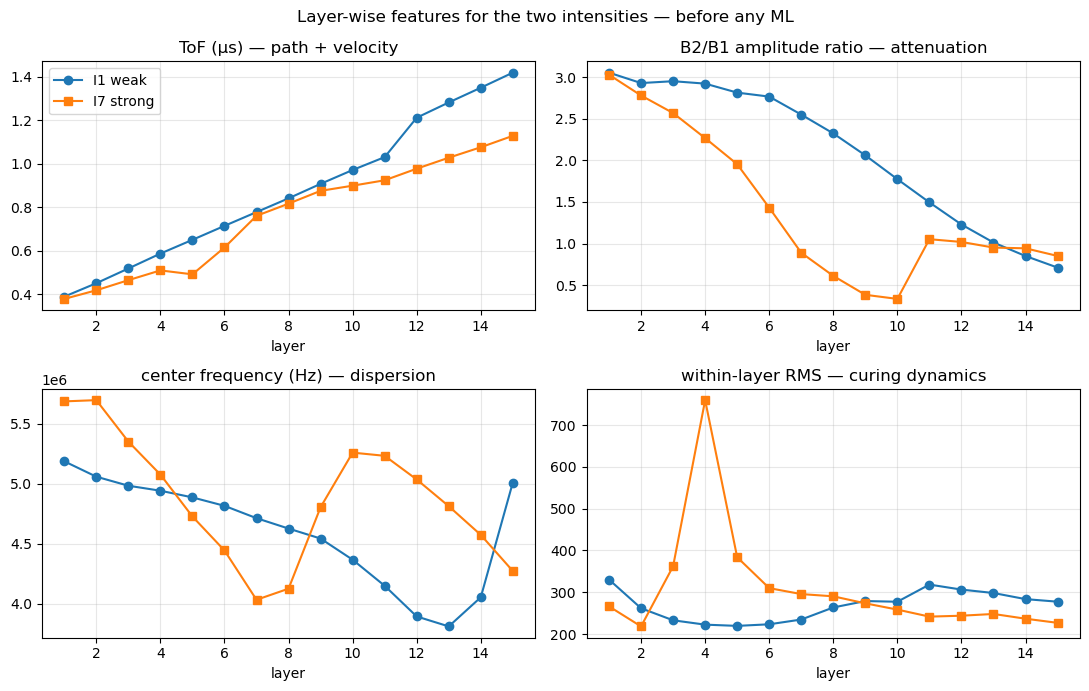

In [5]:
# Four features, one per physical mechanism (see the panel titles).
names = ["ToF", "amplitude", "Center_Freq", "frame_diff_rms"]
titles = ["ToF (µs) — path + velocity", "B2/B1 amplitude ratio — attenuation",
          "center frequency (Hz) — dispersion", "within-layer RMS — curing dynamics"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, n, ti in zip(axes.ravel(), names, titles):
    ax.plot(F1.index, F1[n], "o-", label="I1 weak", color="tab:blue")
    ax.plot(F7.index, F7[n], "s-", label="I7 strong", color="tab:orange")
    ax.set(title=ti, xlabel="layer"); ax.grid(alpha=0.3)
axes[0, 0].legend()
plt.suptitle("Layer-wise features for the two intensities — before any ML")
plt.tight_layout(); plt.show()


**Reading the four panels:**

- *ToF* rises in both prints, because the path keeps growing, and it rises more
  slowly for I7 (about 0.057 versus 0.074 µs per layer): the strongly cured
  material carries sound faster. This is the cleanest signal we have.
- *Amplitude ratio* falls in both prints, and over the first ten layers it
  falls much faster for I7 — more crosslinking, more attenuation. The jump back
  up around layer 11 is almost certainly the tracker latching onto a
  neighbouring peak in a weak signal, a reminder that every feature inherits
  the tracker's mistakes.
- *Center frequency* and *within-layer RMS* have no clear physical reading
  here. The curves differ, but not in a way this pair of prints lets you
  attribute to a cause.

## 3. Where the dataset's features live

Everything so far was recomputed in front of you from three sample prints.
Notebooks 3 and 4 instead use the paper's own tables, covering all 50 printed
cylinders:

- **`data/feature11.csv`** — 50 rows, one per print. Columns: `layer` (10–30),
  `intensity` (percent of lamp power, 10 = I1 … 100 = I10), and
  `Layer_{i}_{feature}` for i = 1…30 and the 11 features above, i.e. **330
  columns**. The 30 slots are fixed width, so a 15-layer print fills slots 1–15
  and leaves the rest at **zero**; any statistic over the slots must therefore
  be restricted to a print's real layers.
- **`data/condition_labels.csv`** — the same 50 rows in the same order, with
  the measured `thickness` (mm, Keyence), `modulus` (Pa, rheometer) and `DoC`
  (–, Raman).

---

**Input** — `data/feature11.csv`.

**What this cell does** — loads the table and prints its shape, the features
stored per layer slot, and one print's padding.

**Output** — `df`, used by the heatmaps below and by both remaining notebooks.


In [6]:
import re

# The paper's own feature table: 50 rows (one per printed sample), wide format
# with columns Layer_1_ToF ... Layer_30_within_layer_std.
df = iu.load_features("data/feature11.csv")
print("table shape (rows = printed samples, columns):", df.shape)
print("non-layer columns:", [c for c in df.columns if not c.startswith("Layer_")])

# Which features are stored for each of the 30 layer slots?
bases = sorted({re.match(r"Layer_(\d+)_(.+)", c).group(2)
                for c in df.columns if c.startswith("Layer_")})
print(f"\n{len(bases)} features per layer slot:")
for b in bases:
    print("   ", b)

# Zero padding, made concrete: this print has 15 layers, so slots 16-30 are 0.
row = df[(df.layer == 15) & (df.intensity == 10)].iloc[0]
print("\n15-layer print at 10% lamp power — stored ToF per layer slot (µs):")
print("   slots  1- 3:", [round(float(row[f"Layer_{i}_ToF"]), 3) for i in (1, 2, 3)])
print("   slots 14-17:", [round(float(row[f"Layer_{i}_ToF"]), 3) for i in (14, 15, 16, 17)],
      "<- slots 16+ are zero padding")


table shape (rows = printed samples, columns): (50, 336)
non-layer columns: ['layer', 'intensity', 'thickness', 'modulus', 'DoC', 'sample_id']

11 features per layer slot:
    Bandwidth
    Center_Freq
    RMS_Energy
    ToF
    Wavelet_Energy_L0
    Wavelet_Energy_L1
    Wavelet_Energy_L2
    Wavelet_Energy_L3
    amplitude
    frame_diff_rms
    within_layer_std

15-layer print at 10% lamp power — stored ToF per layer slot (µs):
   slots  1- 3: [0.414, 0.473, 0.542]
   slots 14-17: [1.207, 1.255, 0.0, 0.0] <- slots 16+ are zero padding


## 4. The whole design grid at a glance — feature heatmaps

Now the full 50-sample table, so the same question can be asked of the whole
design instead of one pair of prints: does a feature respond to exposure?

---

**Input** — the **30-layer group** of `df`: 10 prints, one per intensity.

**What this cell does** — arranges each feature into a (30 layers × 10
intensities) matrix, draws it as an image (vertical = depth, horizontal =
dose), and prints the column averages behind the colours.

**Output** — three heatmaps and their numbers. ToF has a strong depth gradient;
the other two show no clean trend with exposure. No single feature reads out
the process state on its own — which is why Notebook 3 builds a model over all
of them at once.


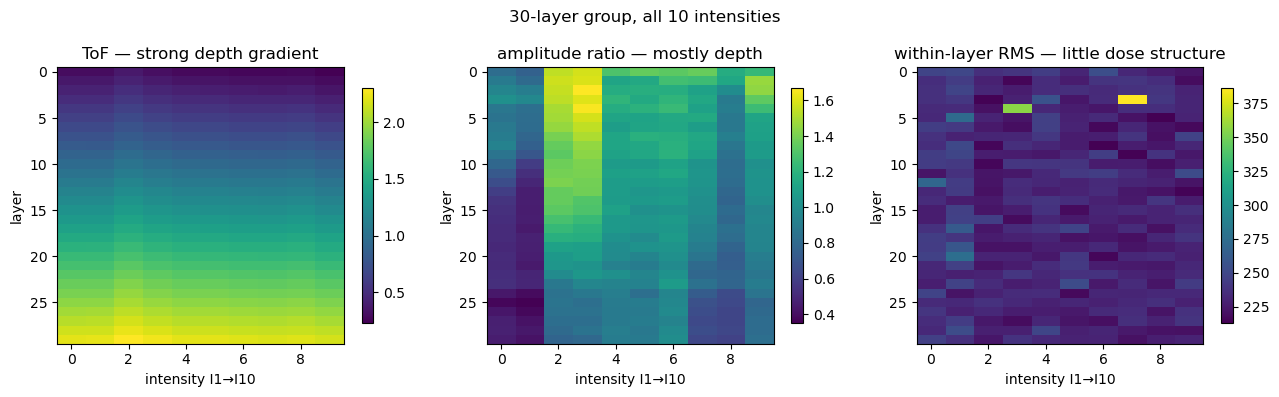

column average over the 30 layers, for intensities I1 -> I10:
  ToF             [1.256 1.256 1.332 1.281 1.246 1.244 1.227 1.222 1.237 1.192]
  amplitude       [0.653 0.576 1.224 1.256 1.049 1.041 1.09  0.959 0.813 1.019]
  frame_diff_rms  [238.159 244.034 226.703 233.549 235.22  231.107 230.484 234.881 228.319
 230.963]


In [7]:
def heat(ax, base, group_layers, title, cmap="viridis"):
    """Draw a (layer × intensity) heatmap of one feature for one layer group."""
    g = df[df.layer == group_layers].sort_values("intensity")   # 10 prints, I1..I10
    # Build the matrix column by column (one column per print), then transpose
    # so that rows = layers (depth) and columns = intensity (dose).
    M = np.array([[r[f"Layer_{i}_{base}"] for i in range(1, group_layers + 1)]
                  for _, r in g.iterrows()]).T          # layers × intensities
    im = ax.imshow(M, aspect="auto", origin="upper", cmap=cmap)
    ax.set(xlabel="intensity I1→I10", ylabel="layer", title=title)
    return im

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
BASES_SHOWN = ["ToF", "amplitude", "frame_diff_rms"]
for ax, base, ti in zip(axes, BASES_SHOWN,
        ["ToF — strong depth gradient", "amplitude ratio — mostly depth",
         "within-layer RMS — little dose structure"]):
    im = heat(ax, base, 30, ti)
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle("30-layer group, all 10 intensities")
plt.tight_layout(); plt.show()

# Check the colours as numbers: average each feature down the 30 layers, so what
# is left is its response to exposure alone.
g = df[df.layer == 30].sort_values("intensity")
print("column average over the 30 layers, for intensities I1 -> I10:")
for base in BASES_SHOWN:
    M = np.array([[r[f"Layer_{i}_{base}"] for i in range(1, 31)]
                  for _, r in g.iterrows()])
    print(f"  {base:15s}", np.round(M.mean(axis=1), 3))


**Next notebook:** we assemble the 344-dimensional representation and learn —
without fooling ourselves.
